In [1]:
import hoda
import tensorly as tl
import mne

!pip install line_profiler
%load_ext line_profiler
mne.set_log_level('ERROR')
tl.get_backend()


[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python3 -m pip install --upgrade pip
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler


paradigm = P300(resample=48)
dataset = BI2013a()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[1],
     return_epochs=True
)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
meta

,subject,session,run
0,1,0,2
1,1,0,2
2,1,0,2
3,1,0,2
4,1,0,2
...,...,...,...
475,1,0,2
476,1,0,2
477,1,0,2
478,1,0,2


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
import numpy as np
from sklearn.model_selection import train_test_split


X = epochs.get_data()
X = tl.tensor(X)
y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

print(X.shape)
print(X.dtype)
print(X.device)

(480, 16, 48)
float32
<CUDA Device 0>


In [5]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings


bttda = GreedyBTTDA(
    max_blocks=64,
    truncate=True,
    #rank_grid=[1],
    rank_grid=None,
    hoda_params=dict(
        rank=None,
        max_iter=128,
        tol=1e-8,
        init ='eye',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,
       
    ),
    verbose=True,
    extra_train_info=True,
    cv=StratifiedKFold(random_state=42, shuffle=True),
    n_jobs=1,
    
)
bttda.fit(X_train,y_train, X_test=X_test, y_test=y_test)

Model selection block 1/64...


  0%|          | 0/128 [00:00<?, ?it/s]

  0%|          | 0/128 [00:00<?, ?it/s]

  0%|          | 0/128 [00:00<?, ?it/s]

  0%|          | 0/128 [00:00<?, ?it/s]

...

  0%|          | 0/128 [00:00<?, ?it/s]

Fitting block 63/63...


  0%|          | 0/128 [00:00<?, ?it/s]

  0%|          | 0/128 [00:00<?, ?it/s]

GreedyBTTDA(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
            extra_train_info=True,
            hoda_params={'delta': None, 'extra_train_info': False,
                         'forward': True, 'init': 'eye', 'max_iter': 128,
                         'obj': 'rt', 'random_state': 42, 'rank': 8,
                         'shrinkage': 'lw', 'solver': 'lanczos', 'taper': False,
                         'toeplitz': None, 'tol': 1e-08, 'verbose': True},
            max_blocks=64, n_jobs=1, verbose=True)

In [6]:

import pandas as pd
df = pd.DataFrame(bttda.model_select_info_)
df_max= df.groupby(['block', 'rank'])
df_max = df_max.aggregate('mean')
df_max=df_max.reset_index()
df_max = df_max.iloc[df_max.groupby('block')['val_score'].idxmax()]
df_max

#sns.lineplotBackward model rank=(16, 16): 8%(data=df, x='block', y='test_score')


/tmp/ipykernel_1017/694680943.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_max = df_max.aggregate('mean')


,block,rank,fold,train_score,val_score
2,0,4,2.0,0.998159,0.956904
9,1,16,2.0,1.000000,0.970500
10,2,1,2.0,1.000000,0.974715
16,3,2,2.0,1.000000,0.974727
22,4,4,2.0,0.999980,0.975051
...,...,...,...,...,...
295,59,1,2.0,1.000000,0.985788
300,60,1,2.0,1.000000,0.985788
308,61,8,2.0,1.000000,0.986432
313,62,8,2.0,1.000000,0.987719


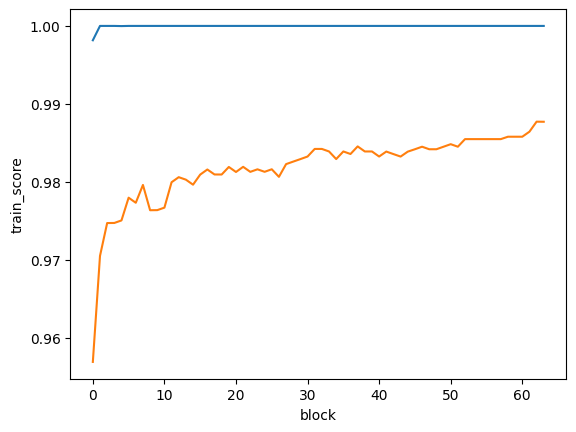

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')
n_samples = X.shape[0]
sns.lineplot(data=df_max, x='block', y='train_score')
sns.lineplot(data=df_max, x='block', y='val_score')
plt.show()


In [8]:
import pandas as pd

df = pd.DataFrame(bttda.train_info_)
df

,block,rank,mse,nmse,F_tr,F_rt,split
0,1,"(4, 4)",1.575117e-10,0.949955,0.523037,0.035251,test
1,1,"(4, 4)",1.533783e-10,0.884942,0.445599,0.027048,train
2,2,"(16, 16)",9.899492e-11,0.597040,0.100511,0.082736,test
3,2,"(16, 16)",9.012450e-11,0.519988,0.068158,0.047124,train
4,3,"(1, 1)",9.891822e-11,0.596577,0.100809,0.083809,test
...,...,...,...,...,...,...,...
121,61,"(1, 1)",2.294814e-11,0.132403,0.060292,0.128374,train
122,62,"(8, 8)",2.561361e-11,0.154476,0.085295,0.339622,test
123,62,"(8, 8)",2.041928e-11,0.117812,0.060113,0.134191,train
124,63,"(8, 8)",2.241373e-11,0.135178,0.085062,0.356960,test


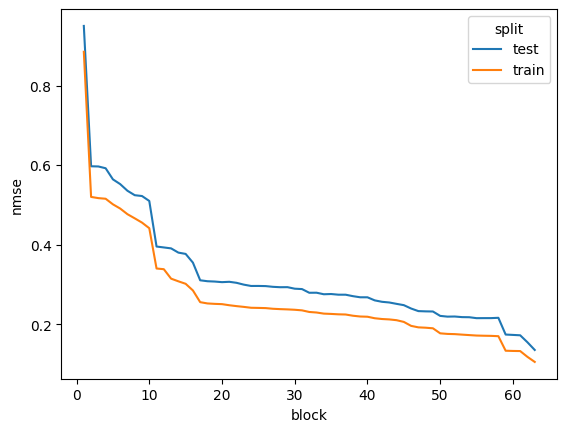

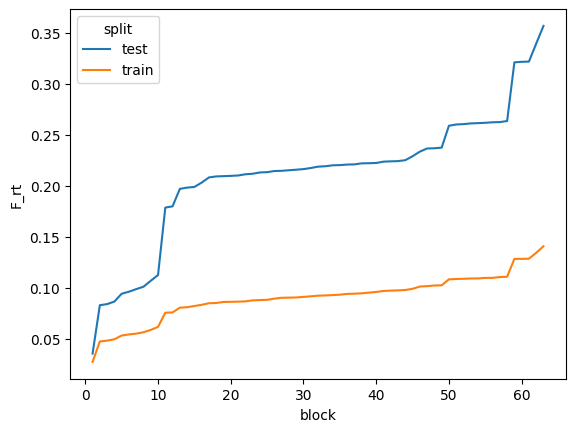

In [9]:

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')
import pandas as pd
df = pd.DataFrame(bttda.train_info_)
df
if bttda.extra_train_info:
    n_samples = X.shape[0]
    sns.lineplot(data=df, x='block', y='nmse', hue='split')
    plt.show()
    sns.lineplot(data=df,x='block',y='F_rt', hue='split')

In [10]:
Xt = bttda.transform(X)
Xt_flat = tl.to_numpy(Xt)

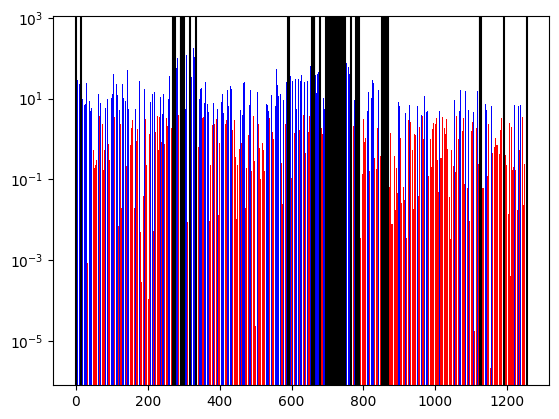

In [11]:
import scipy.stats
import seaborn as sns
import math
import numpy as np

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)
fig, ax = plt.subplots(1,1)
sig_idc = p < 0.05
plt.bar(np.arange(len(F))[sig_idc],F[sig_idc], color='blue')
plt.bar(np.arange(len(F))[~sig_idc],F[~sig_idc], color='red')
plt.yscale('log')
n_params=0
plt.axvline(n_params-.5, color='black')
for b,block in enumerate(bttda.blocks_):
    n_params+=math.prod(block.rank_)
    plt.axvline(n_params-.5, color='black')

<Axes: >

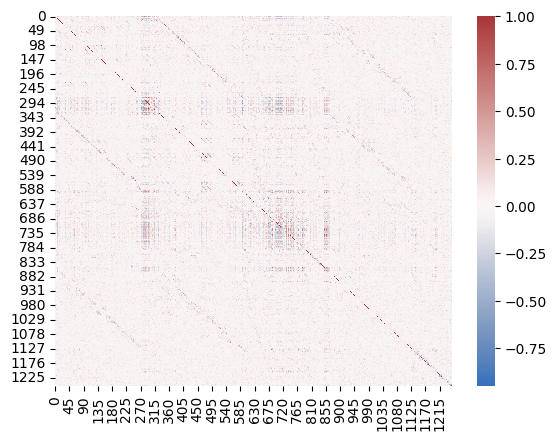

In [12]:
sns.heatmap(np.corrcoef(Xt_flat, rowvar=False),  cmap='vlag', center=0)

     index       PC1       PC2      label
0        0 -0.234649 -0.780376  NonTarget
1        1 -0.736038  1.275559  NonTarget
2        2 -0.461470 -0.247254     Target
3        3  0.895115 -0.911967  NonTarget
4        4  0.875135 -1.432303  NonTarget
..     ...       ...       ...        ...
475    475 -0.173441  0.049168  NonTarget
476    476  0.308328 -0.566124  NonTarget
477    477 -1.260379 -0.226060     Target
478    478  0.424801 -0.890303  NonTarget
479    479 -0.296774  0.173660  NonTarget

[480 rows x 4 columns]


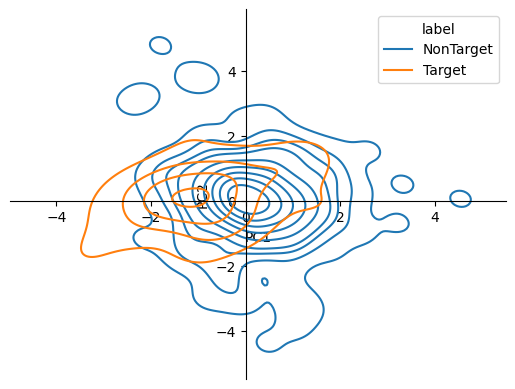

In [13]:
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib import pyplot as plt

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(Xt_flat)
    df = pd.DataFrame(Xt_viz, columns=['PC1', 'PC2'])
    df['label'] = y
    df=df.reset_index()
    print(df)
    #sns.scatterplot(data=df, x='PC1', y='PC2', hue='label',)
    sns.kdeplot(data=df, x='PC1', y='PC2', hue='label',)
    ax = plt.gca()    
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)